# Khám phá dữ liệu MVTec Anomaly Detection Dataset
Notebook này chứa các cell thống kê đơn giản như:
- Dataset overview: Tổng số file
- Định dạng file có trong dataset
- Image count theo class (Train / Test / Ground Truth Masks)
- Class distribution
- Kiểm tra kích thước hình ảnh đồng nhất

In [12]:
import os
import glob
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Đường dẫn tới dataset
DATASET_PATH = r'd:\KLCN-2026\data\mvtec_anomaly_detection'

## 1. Dataset overview: File count & Định dạng file

In [13]:
all_files = []
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        all_files.append(os.path.join(root, file))

print(f"Tổng số file trong dataset: {len(all_files)}")

# Thống kê định dạng file
extensions = [os.path.splitext(f)[1].lower() for f in all_files]
ext_counts = Counter(extensions)
print("\nĐịnh dạng file:")
for ext, count in ext_counts.items():
    print(f"- {ext if ext else 'No extension'}: {count} files")

Tổng số file trong dataset: 6644

Định dạng file:
- .txt: 32 files
- .png: 6612 files


## 2. Image count theo class & 3. Class distribution

In [14]:
classes = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
print(f"Tổng số classes: {len(classes)}\n")

stats = []
for cls in classes:
    train_path = os.path.join(DATASET_PATH, cls, 'train')
    test_path = os.path.join(DATASET_PATH, cls, 'test')
    gt_path = os.path.join(DATASET_PATH, cls, 'ground_truth')
    
    train_imgs = []
    if os.path.exists(train_path):
        train_imgs = glob.glob(os.path.join(train_path, '**', '*.*'), recursive=True)
        train_imgs = [f for f in train_imgs if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))]
        
    test_imgs = []
    if os.path.exists(test_path):
        test_imgs = glob.glob(os.path.join(test_path, '**', '*.*'), recursive=True)
        test_imgs = [f for f in test_imgs if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))]
        
    gt_imgs = []
    if os.path.exists(gt_path):
        gt_imgs = glob.glob(os.path.join(gt_path, '**', '*.*'), recursive=True)
        gt_imgs = [f for f in gt_imgs if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))]
        
    stats.append({
        'Class': cls,
        'Train Images': len(train_imgs),
        'Test Images': len(test_imgs),
        'Ground Truth Masks': len(gt_imgs),
        'Total Images (Train+Test)': len(train_imgs) + len(test_imgs)
    })

df_stats = pd.DataFrame(stats)
# Hiển thị bảng phân bố
display(df_stats)

Tổng số classes: 15



,Class,Train Images,Test Images,Ground Truth Masks,Total Images (Train+Test)
0,bottle,209,83,63,292
1,cable,224,150,92,374
2,capsule,219,132,109,351
3,carpet,280,117,89,397
4,grid,264,78,57,342
5,hazelnut,391,110,70,501
6,leather,245,124,92,369
7,metal_nut,220,115,93,335
8,pill,267,167,141,434
9,screw,320,160,119,480


## Trực quan hóa Class distribution

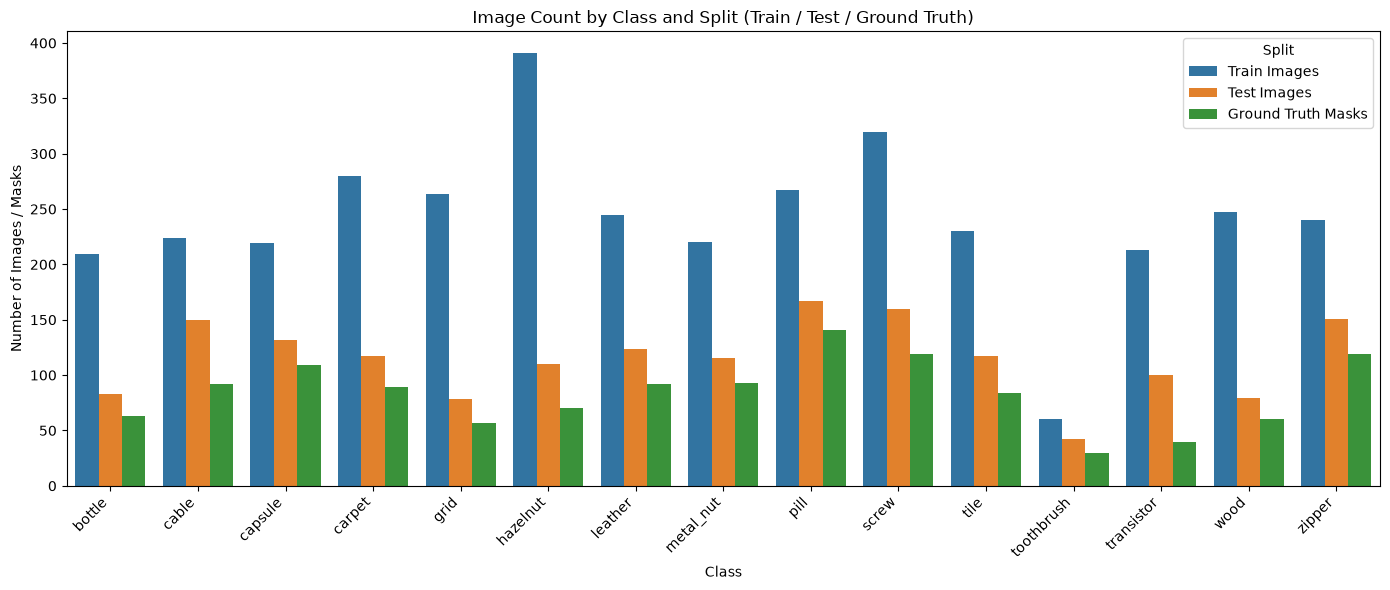

In [15]:
df_melted = df_stats.melt(id_vars='Class', value_vars=['Train Images', 'Test Images', 'Ground Truth Masks'], var_name='Split', value_name='Count')

plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x='Class', y='Count', hue='Split')
plt.xticks(rotation=45, ha='right')
plt.title('Image Count by Class and Split (Train / Test / Ground Truth)')
plt.ylabel('Number of Images / Masks')
plt.xlabel('Class')
plt.tight_layout()
plt.show()

## 4. Kiểm tra kích thước hình ảnh (Resolution Check)
Kiểm tra xem các ảnh trong `train`, `test`, `ground_truth` có cùng kích thước (Width, Height) hay không. Nếu có ảnh khác kích thước, in ra đường dẫn của chúng.

In [16]:
def check_image_sizes(dataset_path):
    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    
    for cls in classes:
        print(f"\n{'='*10} Class: {cls} {'='*10}")
        for split in ['train', 'test', 'ground_truth']:
            split_path = os.path.join(dataset_path, cls, split)
            if not os.path.exists(split_path):
                continue
                
            imgs = glob.glob(os.path.join(split_path, '**', '*.*'), recursive=True)
            imgs = [f for f in imgs if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))]
            
            if not imgs:
                continue
                
            sizes_dict = {}
            for img_path in imgs:
                try:
                    with Image.open(img_path) as img:
                        size = img.size # (width, height)
                        if size not in sizes_dict:
                            sizes_dict[size] = []
                        sizes_dict[size].append(img_path)
                except Exception as e:
                    print(f"Error reading {img_path}: {e}")
            
            print(f"  [{split.upper()}] Các kích thước (W, H) tìm thấy: {list(sizes_dict.keys())}")
            
            # Kiểm tra xem có đồng nhất không
            if len(sizes_dict) > 1:
                print(f"  -> PHÁT HIỆN KÍCH THƯỚC KHÔNG ĐỒNG NHẤT TRONG {split.upper()} CỦA {cls}!")
                # Tìm kích thước phổ biến nhất (majority)
                majority_size = max(sizes_dict, key=lambda k: len(sizes_dict[k]))
                
                # In ra các file có kích thước khác majority
                for size, files in sizes_dict.items():
                    if size != majority_size:
                        print(f"     * Các file có kích thước bất thường {size}:")
                        for f in files[:10]: # in tối đa 10 file để tránh log quá dài
                            print(f"       - {f}")
                        if len(files) > 10:
                            print(f"       ... và {len(files) - 10} file khác.")

# Chạy kiểm tra
check_image_sizes(DATASET_PATH)


========== Class: bottle ==========
  [TRAIN] Các kích thước (W, H) tìm thấy: [(900, 900)]
  [TEST] Các kích thước (W, H) tìm thấy: [(900, 900)]
  [GROUND_TRUTH] Các kích thước (W, H) tìm thấy: [(900, 900)]

========== Class: cable ==========
  [TRAIN] Các kích thước (W, H) tìm thấy: [(1024, 1024)]
  [TEST] Các kích thước (W, H) tìm thấy: [(1024, 1024)]
  [GROUND_TRUTH] Các kích thước (W, H) tìm thấy: [(1024, 1024)]

========== Class: capsule ==========
  [TRAIN] Các kích thước (W, H) tìm thấy: [(1000, 1000)]
  [TEST] Các kích thước (W, H) tìm thấy: [(1000, 1000)]
  [GROUND_TRUTH] Các kích thước (W, H) tìm thấy: [(1000, 1000)]

========== Class: carpet ==========
  [TRAIN] Các kích thước (W, H) tìm thấy: [(1024, 1024)]
  [TEST] Các kích thước (W, H) tìm thấy: [(1024, 1024)]
  [GROUND_TRUTH] Các kích thước (W, H) tìm thấy: [(1024, 1024)]

========== Class: grid ==========
  [TRAIN] Các kích thước (W, H) tìm thấy: [(1024, 1024)]
  [TEST] Các kích thước (W, H) tìm thấy: [(1024, 1024)]
  